---

_You are currently looking at **version 1.0** of this notebook. To download notebooks and datafiles, as well as get help on Jupyter notebooks in the Coursera platform, visit the [Jupyter Notebook FAQ](https://www.coursera.org/learn/python-social-network-analysis/resources/yPcBs) course resource._

---

# Assignment 4

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import pickle
%matplotlib inline

---

## Part 1 - Random Graph Identification

For the first part of this assignment you will analyze randomly generated graphs and determine which algorithm created them.

In [2]:
P1_Graphs = pickle.load(open('A4_graphs','rb'))
P1_Graphs

<br>
`P1_Graphs` is a list containing 5 networkx graphs. Each of these graphs were generated by one of three possible algorithms:
* Preferential Attachment (`'PA'`)
* Small World with low probability of rewiring (`'SW_L'`)
* Small World with high probability of rewiring (`'SW_H'`)

Anaylze each of the 5 graphs and determine which of the three algorithms generated the graph.

*The `graph_identification` function should return a list of length 5 where each element in the list is either `'PA'`, `'SW_L'`, or `'SW_H'`.*

In [ ]:
#%matplotlib notebook
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from random import random

def graph_identification():
    
    # Your Code Here
    for G in P1_Graphs:
        #print(G.nodes(data=True))
        #print(G.edges(data=True))
        print(len(G.nodes()), len(G.edges()))
        d = max([G.degree(n) for n in G.nodes()])
        plt.figure(figsize=(15,15))
        c = random()
        nx.draw_spring(G,  
                     node_color = [(G.degree(n)/float(d), G.degree(n)/float(d), c) for n in G.nodes()], 
                     with_labels = True, 
                     node_size = [2000*G.degree(n)/float(d) for n in G.nodes()],
                     edge_color='lightgray',
                     font_size=6
                  )
        degrees = G.degree()
        labels, values = zip(*Counter(sorted(degrees.values())).items())
        indexes = np.arange(len(labels))
        width = 1
        plt.figure(figsize=(10,10))
        plt.bar(indexes, values, width)
        plt.xticks(indexes + width * 0.5, labels)
        plt.show()

    return ['PA', 'SW_L', 'SW_H', 'PA', 'SW_H'] # Your Answer Here
graph_identification()

---

## Part 2 - Company Emails

For the second part of this assignment you will be workking with a company's email network where each node corresponds to a person at the company, and each edge indicates that at least one email has been sent between two people.

The network also contains the node attributes `Department` and `ManagmentSalary`.

`Department` indicates the department in the company which the person belongs to, and `ManagmentSalary` indicates whether that person is receiving a managment position salary.

Name: 
Type: Graph
Number of nodes: 1005
Number of edges: 16706
Average degree:  33.2458


/opt/conda/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:126: MatplotlibDeprecationWarning: pyplot.hold is deprecated.
    Future behavior will be consistent with the long-time default:
    plot commands add elements without first clearing the
    Axes and/or Figure.
  b = plt.ishold()
/opt/conda/lib/python3.6/site-packages/networkx/drawing/nx_pylab.py:138: MatplotlibDeprecationWarning: pyplot.hold is deprecated.
    Future behavior will be consistent with the long-time default:
    plot commands add elements without first clearing the
    Axes and/or Figure.
  plt.hold(b)
/opt/conda/lib/python3.6/site-packages/matplotlib/__init__.py:917: UserWarning: axes.hold is deprecated. Please remove it from your matplotlibrc and/or style files.
  warnings.warn(self.msg_depr_set % key)
/opt/conda/lib/python3.6/site-packages/matplotlib/rcsetup.py:152: UserWarning: axes.hold is deprecated, will be removed in 3.0
  warnings.warn("axes.hold is deprecated, will be removed in 3.0")


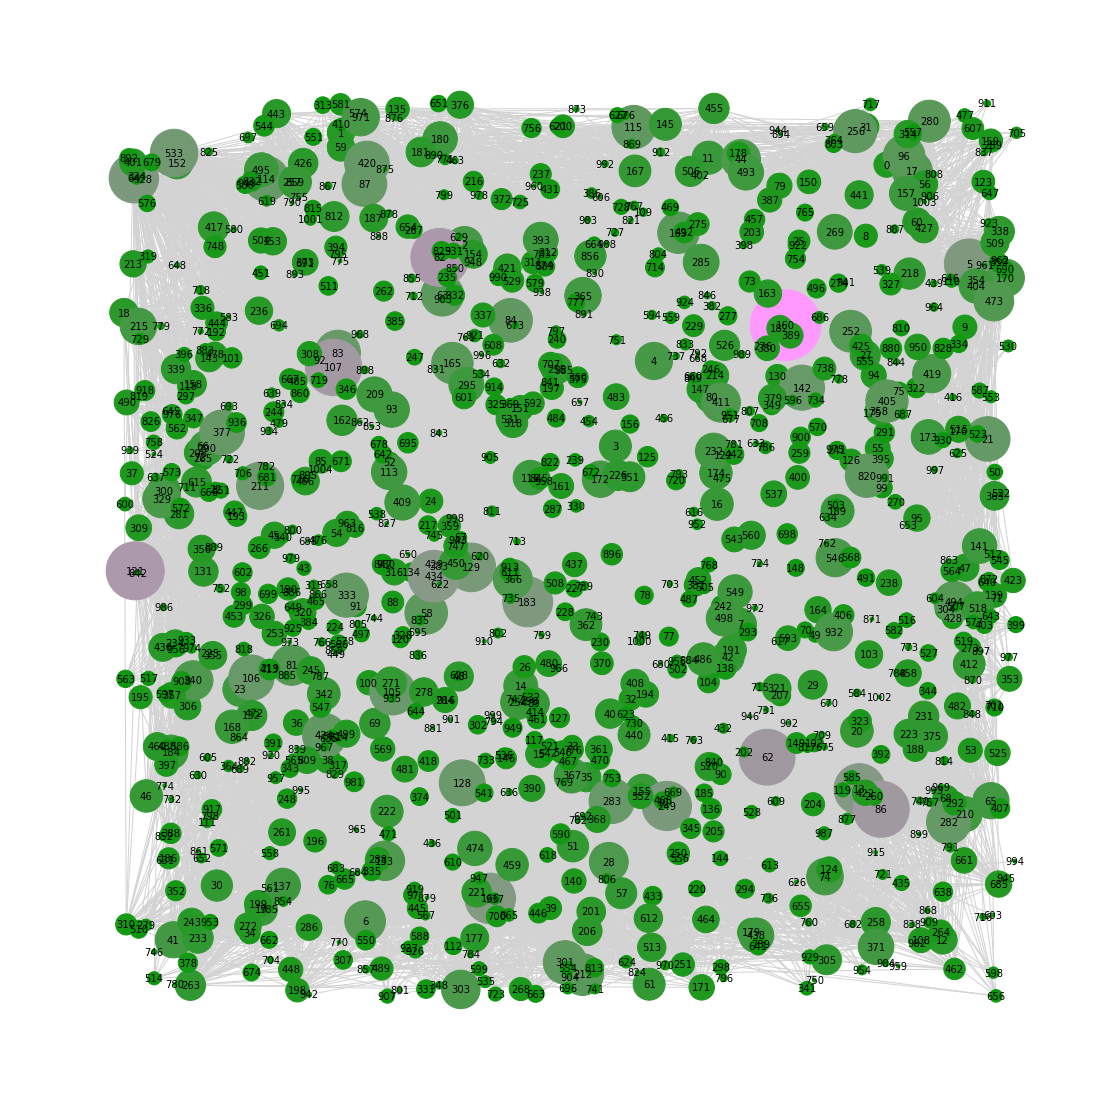

In [2]:
import matplotlib.pyplot as plt
G = nx.read_gpickle('email_prediction.txt')

print(nx.info(G))
d = max([G.degree(n) for n in G.nodes()])
plt.figure(figsize=(15,15))
nx.draw_random(G,  
             node_color = [(G.degree(n)/float(d), 0.6, G.degree(n)/float(d)) for n in G.nodes()], 
             with_labels = True, 
             node_size = [5000*G.degree(n)/float(d) for n in G.nodes()],
             edge_color = 'lightgray',
             font_size=10
          )

### Part 2A - Salary Prediction

Using network `G`, identify the people in the network with missing values for the node attribute `ManagementSalary` and predict whether or not these individuals are receiving a managment position salary.

To accomplish this, you will need to create a matrix of node features using networkx, train a sklearn classifier on nodes that have `ManagementSalary` data, and predict a probability of the node receiving a managment salary for nodes where `ManagementSalary` is missing.



Your predictions will need to be given as the probability that the corresponding employee is receiving a managment position salary.

The evaluation metric for this assignment is the Area Under the ROC Curve (AUC).

Your grade will be based on the AUC score computed for your classifier. A model which with an AUC of 0.75 or higher will receive full points.

Using your trained classifier, return a series of length 252 with the data being the probability of receiving managment salary, and the index being the node id.

    Example:
    
        1       1.0
        2       0.0
        5       0.8
        8       1.0
            ...
        996     0.7
        1000    0.5
        1001    0.0
        Length: 252, dtype: float64

In [24]:
def salary_predictions():
    
    # Your Code Here
    from sklearn.ensemble import RandomForestClassifier 
    from sklearn.svm import SVC
    from sklearn import metrics
    #print(G.nodes(data=True))
    df = pd.DataFrame(index=G.nodes())
    df['Department'] = pd.Series(nx.get_node_attributes(G, 'Department'))
    df['ManagementSalary'] = pd.Series(nx.get_node_attributes(G, 'ManagementSalary'))
    df['clustering'] = pd.Series(nx.clustering(G))
    df['degree'] = pd.Series(G.degree())
    #print(df.head())
    training = df[df['ManagementSalary'].notnull()]
    training['ManagementSalary'] = training['ManagementSalary'].astype(int)
    test = df[df['ManagementSalary'].isnull()]
    #print(training.head())
    #print(test.head())
    Xtrain, ytrain = training[['Department', 'clustering', 'degree']], training['ManagementSalary']
    Xtest = test[['Department', 'clustering', 'degree']]
    #print(Xtest.head())
    #clf = RandomForestClassifier(max_depth=2, random_state=0)
    clf = RandomForestClassifier(random_state=0)
    #clf = SVC(probability=True)
    clf.fit(Xtrain, ytrain)
    ytest = clf.predict_proba(Xtest)
    #ypred = clf.predict_proba(Xtrain)
    #fpr, tpr, thresholds = metrics.roc_curve(ytrain, ypred[:,1], pos_label=1)
    #print(metrics.auc(fpr, tpr))
    return pd.Series(ytest[:,1], index=Xtest.index) # Your Answer Here
#salary_predictions()

In [30]:
#print(G.nodes(data=True))
df = pd.DataFrame(index=G.nodes())
df['Department'] = pd.Series(nx.get_node_attributes(G, 'Department'))
df['ManagementSalary'] = pd.Series(nx.get_node_attributes(G, 'ManagementSalary'))
df['clustering'] = pd.Series(nx.clustering(G))
df['degree'] = pd.Series(G.degree())
df.head(10)

,Department,ManagementSalary,clustering,degree
0,1,0.0,0.276423,44
1,1,NaN,0.265306,52
2,21,NaN,0.297803,95
3,21,1.0,0.384910,71
4,21,1.0,0.318691,96
5,25,NaN,0.107002,171
6,25,1.0,0.155183,115
7,14,0.0,0.287785,72
8,14,NaN,0.447059,37
9,14,0.0,0.425320,40


In [31]:
training = df[df['ManagementSalary'].notnull()]
training['ManagementSalary'] = training['ManagementSalary'].astype(int)
test = df[df['ManagementSalary'].isnull()]
Xtrain, ytrain = training[['Department', 'clustering', 'degree']], training['ManagementSalary']
Xtest = test[['Department', 'clustering', 'degree']]
from sklearn.model_selection import train_test_split
Xtrain, Xvalid, ytrain, yvalid = train_test_split(Xtrain, ytrain, test_size=0.33, random_state=42)
pd.concat([Xtrain, ytrain], axis=1).head(20)

/opt/conda/lib/python3.6/site-packages/ipykernel/__main__.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  from ipykernel import kernelapp as app


,Department,clustering,degree,ManagementSalary
421,14,0.227755,52,0
972,15,0.000000,2,0
322,17,0.578462,28,0
431,37,0.426877,25,0
506,14,0.282514,63,0
634,21,0.000000,3,0
130,0,0.342857,37,0
140,17,0.394062,41,0
338,13,0.350820,63,0
117,6,0.274510,20,0


In [32]:
pd.concat([Xvalid, yvalid], axis=1).head(20)

,Department,clustering,degree,ManagementSalary
952,15,0.533333,8,0
859,32,0.388106,74,1
490,6,0.451220,43,0
98,16,0.525692,25,0
273,17,0.502463,31,0
784,28,0.000000,3,0
750,20,0.000000,1,0
328,8,0.432749,21,0
411,28,0.208364,106,1
908,5,0.566154,28,0


In [33]:
Xtest.head(10)

,Department,clustering,degree
1,1,0.265306,52
2,21,0.297803,95
5,25,0.107002,171
8,14,0.447059,37
14,4,0.215784,80
18,1,0.301188,56
27,11,0.368852,63
30,11,0.402797,68
31,11,0.412234,50
34,11,0.637931,31


0.836320109439
0.75950752394
0.878112175103


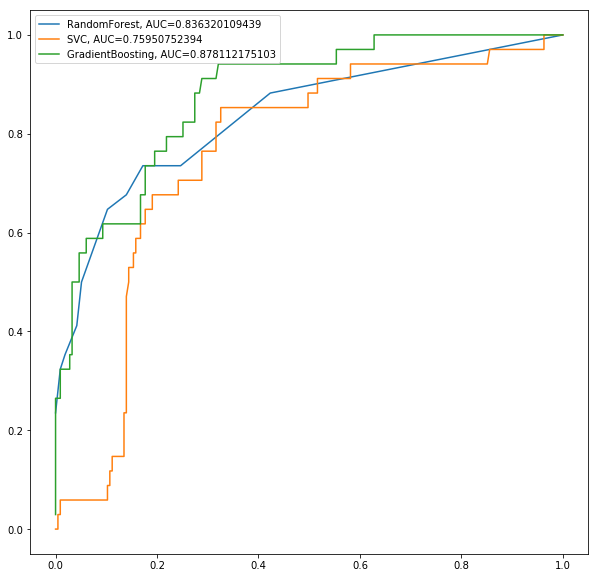

In [34]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.svm import SVC
from sklearn import metrics
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

#print(Xtest.head())
#clf = RandomForestClassifier(max_depth=2, random_state=0)
clf = RandomForestClassifier(random_state=0)
clf2 = SVC(probability=True)
clf3 = GradientBoostingClassifier(random_state=0)
clf.fit(Xtrain, ytrain)
clf2.fit(Xtrain, ytrain)
clf3.fit(Xtrain, ytrain)
ytest = clf.predict_proba(Xtest)
ypred = clf.predict_proba(Xvalid)
ypred2 = clf2.predict_proba(Xvalid)
ypred3 = clf3.predict_proba(Xvalid)
fpr, tpr, thresholds = metrics.roc_curve(yvalid, ypred[:,1], pos_label=1)
print(metrics.auc(fpr, tpr))
auc = metrics.roc_auc_score(yvalid, ypred[:,1])
plt.figure(figsize=(10,10)).clf()
plt.plot(fpr,tpr,label="RandomForest, AUC="+str(auc))
fpr, tpr, thresholds = metrics.roc_curve(yvalid, ypred2[:,1], pos_label=1)
print(metrics.auc(fpr, tpr))
auc = metrics.roc_auc_score(yvalid, ypred2[:,1])
plt.plot(fpr,tpr,label="SVC, AUC="+str(auc))
fpr, tpr, thresholds = metrics.roc_curve(yvalid, ypred3[:,1], pos_label=1)
print(metrics.auc(fpr, tpr))
auc = metrics.roc_auc_score(yvalid, ypred3[:,1])
plt.plot(fpr,tpr,label="GradientBoosting, AUC="+str(auc))
plt.legend(loc=0)

In [10]:
pd.DataFrame(ytest).head(20)

,0,1
0,1.0,0.0
1,0.2,0.8
2,0.0,1.0
3,1.0,0.0
4,0.5,0.5
5,1.0,0.0
6,0.7,0.3
7,0.7,0.3
8,0.3,0.7
9,0.7,0.3


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
print(df.max(), df.min())
#print(Xtest.columns.values)
x, y, z = np.meshgrid(np.linspace(0,42,30).astype(int), np.linspace(0.,1.,30), np.linspace(1,348,30).astype(int), sparse=False, indexing='ij')
#for i in range(10):
#    for j in range(10):
#        for k in range(10):
#            clf.predict(Xtest)
#            xtest = pd.DataFrame([[x[i,j,k], y[i,j,k], z[i,j,k]]], columns=Xtest.columns.values)
#            ytest = clf.predict(xtest)
#            #print(xtest, ytest)
#            ax.scatter(x[i,j,k], y[i,j,k], z[i,j,k], c=('r' if ytest==1. else 'b'), marker=('+' if ytest==1. else 'o'))
Xtest = np.array([x, y, z]).reshape(3, -1).T
ytest = clf.predict(Xtest)
#ytest = clf.predict_proba(Xtest)[:,1]
cm = plt.cm.get_cmap('inferno') #('seismic')
sc = ax.scatter(Xtest[:,0], Xtest[:,1], Xtest[:,2], c=ytest, s=35, cmap=cm)#, marker=np.array(['x' if y==1. else 'o' for y in ytest])
#ax.set_xlim([0, 41])
#ax.set_ylim([0, 1])
#ax.set_zlim([1, 347])
ax.set_xlabel('Department')
ax.set_ylabel('Clustering')
ax.set_zlabel('Degree')
plt.colorbar(sc)
plt.show()

Department           41.0
ManagementSalary      1.0
clustering            1.0
degree              347.0
dtype: float64 Department          0.0
ManagementSalary    0.0
clustering          0.0
degree              1.0
dtype: float64


### Part 2B - New Connections Prediction

For the last part of this assignment, you will predict future connections between employees of the network. The future connections information has been loaded into the variable `future_connections`. The index is a tuple indicating a pair of nodes that currently do not have a connection, and the `Future Connection` column indicates if an edge between those two nodes will exist in the future, where a value of 1.0 indicates a future connection.

In [4]:
future_connections = pd.read_csv('Future_Connections.csv', index_col=0, converters={0: eval})
future_connections.head(10)

,Future Connection
"(6, 840)",0.0
"(4, 197)",0.0
"(620, 979)",0.0
"(519, 872)",0.0
"(382, 423)",0.0
"(97, 226)",1.0
"(349, 905)",0.0
"(429, 860)",0.0
"(309, 989)",0.0
"(468, 880)",0.0


Using network `G` and `future_connections`, identify the edges in `future_connections` with missing values and predict whether or not these edges will have a future connection.

To accomplish this, you will need to create a matrix of features for the edges found in `future_connections` using networkx, train a sklearn classifier on those edges in `future_connections` that have `Future Connection` data, and predict a probability of the edge being a future connection for those edges in `future_connections` where `Future Connection` is missing.



Your predictions will need to be given as the probability of the corresponding edge being a future connection.

The evaluation metric for this assignment is the Area Under the ROC Curve (AUC).

Your grade will be based on the AUC score computed for your classifier. A model which with an AUC of 0.75 or higher will receive full points.

Using your trained classifier, return a series of length 122112 with the data being the probability of the edge being a future connection, and the index being the edge as represented by a tuple of nodes.

    Example:
    
        (107, 348)    0.35
        (542, 751)    0.40
        (20, 426)     0.55
        (50, 989)     0.35
                  ...
        (939, 940)    0.15
        (555, 905)    0.35
        (75, 101)     0.65
        Length: 122112, dtype: float64

In [25]:
def new_connections_predictions():
    
    # Your Code Here
    #print(G.edges(data=True))
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
    from sklearn.svm import SVC
    from sklearn import metrics
    future_connections['preferential attachment'] = [i[2] for i in nx.preferential_attachment(G, future_connections.index)]
    future_connections['Common Neighbors'] = future_connections.index.map(lambda e: len(list(nx.common_neighbors(G, e[0], e[1]))))    
    #print(future_connections.head())
    training = future_connections[~future_connections['Future Connection'].isnull()]
    training['Future Connection'] = training['Future Connection'].astype(int)
    test = future_connections[future_connections['Future Connection'].isnull()]
    #print(training.head())
    #print(test.head())
    Xtrain, ytrain = training[['preferential attachment', 'Common Neighbors']], training['Future Connection']
    Xtest = test[['preferential attachment', 'Common Neighbors']]
    #print(Xtest.head())
    #clf = RandomForestClassifier(max_depth=2, random_state=0)
    #clf = RandomForestClassifier(random_state=0)
    clf = GradientBoostingClassifier()
    #clf = SVC(probability=True)
    clf.fit(Xtrain, ytrain)
    ytest = clf.predict_proba(Xtest)
    #ypred = clf.predict_proba(Xtrain)
    #fpr, tpr, thresholds = metrics.roc_curve(ytrain, ypred[:,1], pos_label=1)
    #print(metrics.auc(fpr, tpr))
    return pd.Series(ytest[:,1], index=Xtest.index) # Your Answer Here
#new_connections_predictions()

In [5]:
future_connections['preferential attachment'] = [i[2] for i in nx.preferential_attachment(G, future_connections.index)]
future_connections['Common Neighbors'] = future_connections.index.map(lambda e: len(list(nx.common_neighbors(G, e[0], e[1])))) 
future_connections.head(20)

,Future Connection,preferential attachment,Common Neighbors
"(6, 840)",0.0,2070,9
"(4, 197)",0.0,3552,2
"(620, 979)",0.0,28,0
"(519, 872)",0.0,299,2
"(382, 423)",0.0,205,0
"(97, 226)",1.0,1575,4
"(349, 905)",0.0,240,0
"(429, 860)",0.0,816,0
"(309, 989)",0.0,184,0
"(468, 880)",0.0,672,1


In [6]:
training = future_connections[~future_connections['Future Connection'].isnull()]
training['Future Connection'] = training['Future Connection'].astype(int)
test = future_connections[future_connections['Future Connection'].isnull()]
#print(training.head())
#print(test.head())
Xtrain, ytrain = training[['preferential attachment', 'Common Neighbors']], training['Future Connection']
Xtest = test[['preferential attachment', 'Common Neighbors']]
from sklearn.model_selection import train_test_split
Xtrain, Xvalid, ytrain, yvalid = train_test_split(Xtrain, ytrain, test_size=0.33, random_state=42)
pd.concat([Xtrain, ytrain], axis=1).head(20)    

/opt/conda/lib/python3.6/site-packages/ipykernel/__main__.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  from ipykernel import kernelapp as app


,preferential attachment,Common Neighbors,Future Connection
"(7, 793)",360,0,0
"(171, 311)",1620,1,0
"(548, 651)",684,2,0
"(364, 988)",18,0,0
"(217, 981)",648,0,0
"(73, 398)",124,0,0
"(284, 837)",132,1,0
"(748, 771)",272,4,0
"(79, 838)",88,0,0
"(207, 716)",90,1,1


In [7]:
pd.concat([Xvalid, yvalid], axis=1).head(20)

,preferential attachment,Common Neighbors,Future Connection
"(225, 382)",150,0,0
"(219, 444)",594,0,0
"(911, 999)",3,0,0
"(363, 668)",57,0,0
"(161, 612)",2408,4,0
"(98, 519)",575,0,0
"(59, 623)",636,0,0
"(373, 408)",2576,6,0
"(948, 981)",27,0,0
"(690, 759)",44,0,0


In [8]:
Xtest.head(10)

,preferential attachment,Common Neighbors
"(107, 348)",884,2
"(542, 751)",126,0
"(20, 426)",4440,10
"(50, 989)",68,0
"(942, 986)",6,0
"(324, 857)",76,0
"(13, 710)",3600,6
"(19, 271)",5040,6
"(319, 878)",48,0
"(659, 707)",120,0


0.831664533372
0.907511048978


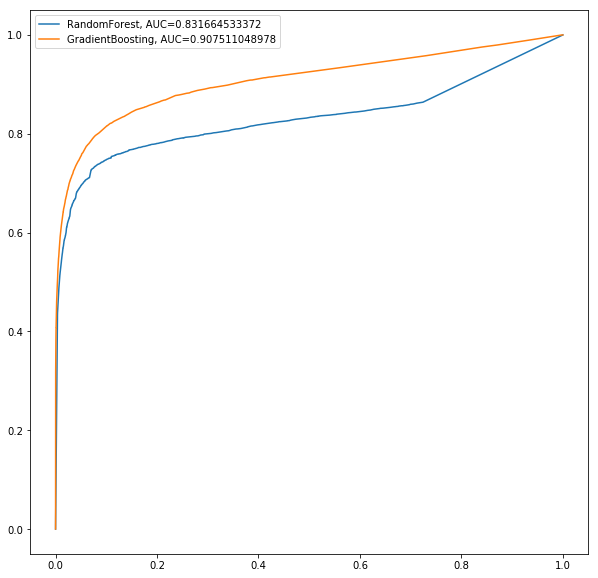

In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.svm import SVC
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

#print(Xtest.head())
#clf = RandomForestClassifier(max_depth=2, random_state=0)
clf = RandomForestClassifier(random_state=0)
#clf2 = SVC(probability=True)
clf3 = GradientBoostingClassifier(random_state=0)
clf.fit(Xtrain, ytrain)
#clf2.fit(Xtrain, ytrain)
clf3.fit(Xtrain, ytrain)
ytest = clf.predict_proba(Xtest)
ypred = clf.predict_proba(Xvalid)
#ypred2 = clf2.predict_proba(Xvalid)
ypred3 = clf3.predict_proba(Xvalid)
fpr, tpr, thresholds = metrics.roc_curve(yvalid, ypred[:,1], pos_label=1)
print(metrics.auc(fpr, tpr))
auc = metrics.roc_auc_score(yvalid, ypred[:,1])
plt.figure(figsize=(10,10)).clf()
plt.plot(fpr,tpr,label="RandomForest, AUC="+str(auc))
#fpr, tpr, thresholds = metrics.roc_curve(yvalid, ypred2[:,1], pos_label=1)
#print(metrics.auc(fpr, tpr))
#auc = metrics.roc_auc_score(yvalid, ypred2[:,1])
#plt.plot(fpr,tpr,label="SVC, AUC="+str(auc))
fpr, tpr, thresholds = metrics.roc_curve(yvalid, ypred3[:,1], pos_label=1)
print(metrics.auc(fpr, tpr))
auc = metrics.roc_auc_score(yvalid, ypred3[:,1])
plt.plot(fpr,tpr,label="GradientBoosting, AUC="+str(auc))
plt.legend(loc=0)

Future Connection              1.0
preferential attachment    75646.0
Common Neighbors             161.0
dtype: float64 Future Connection          0.0
preferential attachment    1.0
Common Neighbors           0.0
dtype: float64


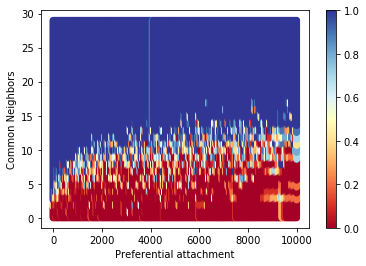

In [22]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure()#figsize=(10,10))
print(future_connections.max(), future_connections.min())
x, y = np.meshgrid(np.linspace(1,10000,200).astype(int), np.linspace(0,29,200), sparse=False, indexing='ij')
Xtest = np.array([x, y]).reshape(2, -1).T
#ytest = clf.predict(Xtest)
ytest = clf.predict_proba(Xtest)[:,1]
cm = plt.cm.get_cmap('RdYlBu')
sc = plt.scatter(Xtest[:,0], Xtest[:,1], c=ytest, s=35, cmap=cm)#, marker=np.array(['x' if y==1. else 'o' for y in ytest])
plt.xlabel('Preferential attachment')
plt.ylabel('Common Neighbors')
plt.colorbar(sc)
plt.show()

Future Connection              1.0
preferential attachment    75646.0
Common Neighbors             161.0
dtype: float64 Future Connection          0.0
preferential attachment    1.0
Common Neighbors           0.0
dtype: float64


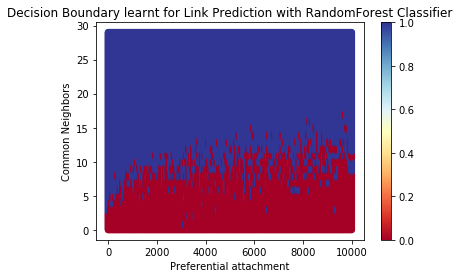

In [24]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure()#figsize=(10,10))
print(future_connections.max(), future_connections.min())
x, y = np.meshgrid(np.linspace(1,10000,200).astype(int), np.linspace(0,29,200), sparse=False, indexing='ij')
Xtest = np.array([x, y]).reshape(2, -1).T
ytest = clf.predict(Xtest)
#ytest = clf.predict_proba(Xtest)[:,1]
cm = plt.cm.get_cmap('RdYlBu')
sc = plt.scatter(Xtest[:,0], Xtest[:,1], c=ytest, s=35, cmap=cm)#, marker=np.array(['x' if y==1. else 'o' for y in ytest])
plt.xlabel('Preferential attachment')
plt.ylabel('Common Neighbors')
plt.title('Decision Boundary learnt for Link Prediction with RandomForest Classifier')
plt.colorbar(sc)
plt.show()